# B. Logistic Regression
## Predict whether an employee will be promoted


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [2]:
df= pd.read_csv(r"D:\DATA_SCIENCE\employee_promotion_prediction.csv")
df

,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,58,Male,Bachelor,Married,Tier1,HR,Full-time,7,7,...,66709.407346,8.631959,8702.015281,5974.691684,0.869204,0,50.969019,40.829720,70.007765,0
99996,99997,48,Female,PhD,Married,Tier1,Sales,Full-time,1,1,...,126692.866136,8.298289,11794.937090,4772.987201,0.881698,2,66.858201,73.062241,52.235678,0
99997,99998,44,Male,Master,Single,Tier1,Marketing,Full-time,6,5,...,97701.247923,3.808966,12290.380251,4933.996464,0.880806,2,77.376189,33.173988,80.104191,0
99998,99999,47,Female,Master,Single,Tier2,Operations,Full-time,10,0,...,92976.123220,7.207749,6013.059244,5050.752021,0.943993,1,84.417142,55.164958,27.788739,0


In [3]:
data = df [['age','years_at_company','performance_score','training_hours_last_year','projects_completed','salary','promoted']]
data

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary,promoted
0,50,10,100.000000,25.361303,4,137633.720337,0
1,36,9,72.008233,43.760654,9,114499.406460,0
2,29,7,77.244045,25.275693,7,124233.224752,0
3,42,4,49.061426,33.507680,4,100896.326509,0
4,40,2,89.021698,44.730269,6,93054.051809,0
...,...,...,...,...,...,...,...
99995,58,7,65.667405,44.196447,2,66709.407346,0
99996,48,1,65.879533,28.214698,4,126692.866136,0
99997,44,6,74.019251,47.025932,4,97701.247923,0
99998,47,10,42.735590,53.422399,9,92976.123220,0


In [4]:
#Data Information Gathering
df.head()

,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0


In [5]:
df.tail()

,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
99995,99996,58,Male,Bachelor,Married,Tier1,HR,Full-time,7,7,...,66709.407346,8.631959,8702.015281,5974.691684,0.869204,0,50.969019,40.829720,70.007765,0
99996,99997,48,Female,PhD,Married,Tier1,Sales,Full-time,1,1,...,126692.866136,8.298289,11794.937090,4772.987201,0.881698,2,66.858201,73.062241,52.235678,0
99997,99998,44,Male,Master,Single,Tier1,Marketing,Full-time,6,5,...,97701.247923,3.808966,12290.380251,4933.996464,0.880806,2,77.376189,33.173988,80.104191,0
99998,99999,47,Female,Master,Single,Tier2,Operations,Full-time,10,0,...,92976.123220,7.207749,6013.059244,5050.752021,0.943993,1,84.417142,55.164958,27.788739,0
99999,100000,26,Female,Bachelor,Single,Tier3,Finance,Full-time,5,0,...,60513.833314,8.366674,10146.628968,3198.900055,0.878917,2,94.368536,39.103485,43.824709,0


In [6]:
df.shape

(100000, 43)

In [7]:
df.describe()

,employee_id,age,years_at_company,years_in_current_role,years_since_last_promotion,team_size,performance_score,performance_last_year,performance_two_years_ago,manager_rating,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,40.558140,5.489030,2.750630,2.749650,11.014010,70.097429,68.166798,65.102153,3.302642,...,101729.791058,7.401439,10409.710839,5658.466284,0.928158,1.993690,69.916845,67.907766,50.011404,0.100000
std,28867.657797,10.951788,3.481758,2.746004,2.733337,4.910633,14.717013,13.867294,11.773939,0.765938,...,36260.885391,2.029034,2311.368587,1264.375203,0.046578,1.415977,14.719348,15.665689,19.714147,0.300002
min,1.000000,22.000000,0.000000,0.000000,0.000000,3.000000,40.000000,40.000000,40.000000,1.000000,...,27616.720722,0.000000,1945.900012,788.905587,0.727631,0.000000,20.000000,20.000000,0.000000,0.000000
25%,25000.750000,31.000000,3.000000,1.000000,1.000000,7.000000,59.499890,58.357646,56.954026,2.769433,...,83242.514699,6.029638,8812.946506,4809.857296,0.896236,1.000000,59.887391,57.184464,36.534728,0.000000
50%,50000.500000,41.000000,5.000000,2.000000,2.000000,11.000000,69.980013,68.033605,65.018847,3.302663,...,96923.478362,7.399610,10410.582882,5661.913481,0.930238,2.000000,70.025028,68.032234,50.043370,0.000000
75%,75000.250000,50.000000,7.000000,4.000000,4.000000,15.000000,80.596442,77.791895,73.121749,3.837462,...,112448.432831,8.773342,12002.845048,6508.183945,0.963801,3.000000,80.159887,78.895916,63.409152,0.000000
max,100000.000000,59.000000,30.000000,28.000000,29.000000,19.000000,100.000000,100.000000,100.000000,5.000000,...,663817.278916,15.996288,19615.455082,10846.763857,1.000000,12.000000,100.000000,100.000000,100.000000,1.000000


In [9]:
#Data Cleaning
df.isnull().sum()

employee_id                   0
age                           0
gender                        0
education_level               0
marital_status                0
city_tier                     0
department                    0
employment_type               0
years_at_company              0
years_in_current_role         0
years_since_last_promotion    0
team_size                     0
performance_score             0
performance_last_year         0
performance_two_years_ago     0
manager_rating                0
peer_feedback_score           0
projects_completed            0
kpi_achievement_percent       0
innovation_score              0
leadership_score              0
problem_solving_score         0
avg_monthly_hours             0
overtime_hours                0
tasks_completed               0
deadline_adherence_rate       0
meeting_hours_per_month       0
remote_work_ratio             0
training_hours_last_year      0
certifications_count          0
skill_assessment_score        0
cross_de

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#Divide X and Y
x = df[['age','years_at_company','performance_score','training_hours_last_year','projects_completed','salary']]
y = df['promoted']
x

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary
0,50,10,100.000000,25.361303,4,137633.720337
1,36,9,72.008233,43.760654,9,114499.406460
2,29,7,77.244045,25.275693,7,124233.224752
3,42,4,49.061426,33.507680,4,100896.326509
4,40,2,89.021698,44.730269,6,93054.051809
...,...,...,...,...,...,...
99995,58,7,65.667405,44.196447,2,66709.407346
99996,48,1,65.879533,28.214698,4,126692.866136
99997,44,6,74.019251,47.025932,4,97701.247923
99998,47,10,42.735590,53.422399,9,92976.123220


In [12]:
#train-test split
x_train , x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_test

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary
75721,48,11,61.569049,46.592282,5,127269.603922
80184,54,6,44.909208,34.671245,8,104196.216921
19864,40,1,84.727623,54.084261,2,75473.743918
76699,37,4,40.000000,24.813713,2,110146.167810
92991,59,3,56.061030,30.549544,1,70457.941373
...,...,...,...,...,...,...
32595,36,5,75.844916,23.309500,2,91193.256924
29313,38,2,63.002196,38.890553,5,106675.027402
37862,38,7,57.035322,52.725140,1,95890.907997
53421,22,4,47.058619,36.250124,5,65646.026553


In [13]:
#Feature Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
#training the model
classifier = LogisticRegression()
classifier.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [16]:
#testing and prediciton
y_predict = classifier.predict(x_test)

In [17]:
#accuracy
accuracy = accuracy_score(y_test,y_predict)
print("Accuracy=", accuracy)

Accuracy= 0.89515


In [18]:
#confusion matrix
cm = confusion_matrix(y_test,y_predict)
print(cm)

[[17874    55]
 [ 2042    29]]


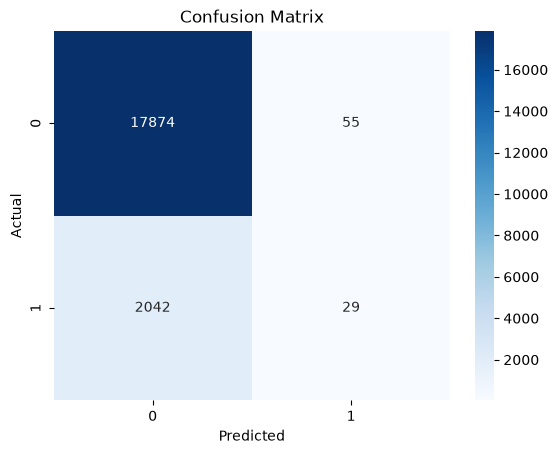

In [19]:
#visualization
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Predict Promotion for New Employee ( 0--> Not to be promoted , 1--> Likely to be Promoted )

In [20]:
new_emp = scaler.transform([[30,5,80,40,12,150000]])
pred = classifier.predict(new_emp)
print(pred)

[0]


C:\Users\prade\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
new_emp = scaler.transform([[30,7,80,40,22,200000]])
pred = classifier.predict(new_emp)
print(pred)

[1]


C:\Users\prade\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
